In [15]:
# Libraries
import sys
sys.path.append("..")
from src.utils import section
import joblib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

In [16]:
df = pd.read_csv("../data/processed/cleaned_ecommerce_data.csv")

In [17]:
from src.pipeline import pipeline_builder
from src.train import full_pipeline_builder

preprocessor = pipeline_builder(df)


logistic_full_pipeline = full_pipeline_builder(df, LogisticRegression(C=1, max_iter=1000))

random_forest_full_pipeline = full_pipeline_builder(df, RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=3, random_state=42))

xgboost_full_pipeline = full_pipeline_builder(df, XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42))

lightgbm_full_pipeline = full_pipeline_builder(df, LGBMClassifier(
    n_estimators=300, num_leaves=15, learning_rate=0.05, random_state=42, verbose=-1))

In [18]:
# Split the data into train train_test_split
from src.train import train_test_splitter


X_train, X_test, y_train, y_test = train_test_splitter(df)

models = {
    "Logistic Regression": logistic_full_pipeline,
    "Random Forest": random_forest_full_pipeline,
    "XGBoost": xgboost_full_pipeline,
    "LightGBM": lightgbm_full_pipeline,
}

models_performance = {}

for model_name, model_pipeline in models.items(): 
    scores = cross_validate(model_pipeline,
                          X_train, y_train, 
                          cv=5, 
                          scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])
    models_performance[model_name] = scores    

In [19]:
rows = {}

for model_name, scores in models_performance.items():
    rows[model_name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
    }

results_df = pd.DataFrame(rows).T
results_df.round(3)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.905,0.924,0.930,0.927,0.972
Random Forest,0.887,0.901,0.928,0.914,0.958
XGBoost,0.895,0.911,0.929,0.920,0.963
LightGBM,0.889,0.909,0.920,0.914,0.961


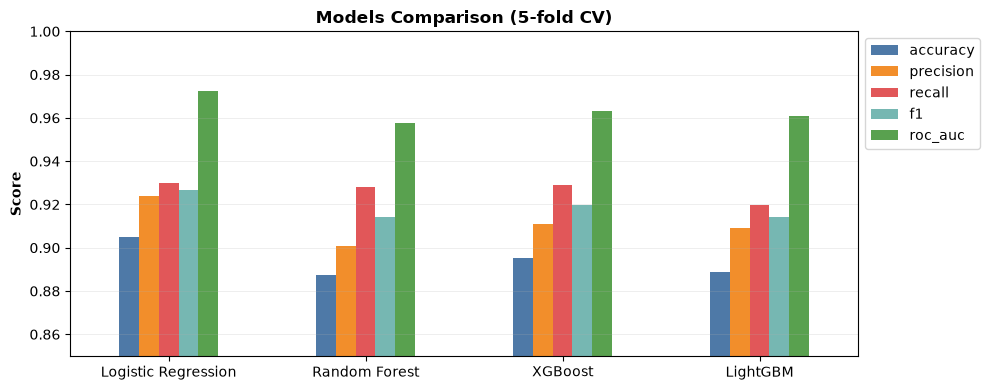

In [20]:
color = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']
results_df.plot(
        kind='bar', 
        figsize=(10,4),
        color = color
        )
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.title("Models Comparison (5-fold CV)", fontweight='bold')
plt.ylabel("Score", fontweight='bold')
plt.ylim(0.85, 1)
plt.tight_layout()
plt.savefig(f'../figures/evaluation/comparison.png', dpi=600, bbox_inches='tight')
plt.show()

In [21]:
# Hyper parameter tuning

section("hyperparemter tuning", 40)
grid_params = {
    "model__C": [1, 10, 100],
    "selector__k": [15, 20, "all"],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    logistic_full_pipeline,
    grid_params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

joblib.dump(best_model, '../../backend/models/return_model.pkl')

print(grid.best_params_)
print(grid.best_score_)

                                        
HYPERPAREMTER TUNING:
{'model__C': 10, 'model__class_weight': None, 'selector__k': 20}
0.954835547781629


In [22]:
# Train the best model
model = best_model
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['cart_value_usd','past_return_rate','size_bracketing_flag',..., 'checkout_device','packaging_color','loyalty_card_color']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...), ('cat_transformer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns a

In [23]:
section("Independent features used", 40)
names = model.named_steps["preprocessor"].get_feature_names_out()
mask = model.named_steps["selector"].get_support()
print(names[mask])

                                        
INDEPENDENT FEATURES USED:
['num_transformer__cart_value_usd' 'num_transformer__past_return_rate'
 'num_transformer__delivery_days_taken'
 'num_transformer__discount_pct_applied'
 'cat_transformer__product_category_Accessories'
 'cat_transformer__product_category_Casual-Tops'
 'cat_transformer__product_category_Footwear'
 'cat_transformer__product_category_Formal-Eveningwear'
 'cat_transformer__fit_review_sentiment_Inconsistent-Sizing'
 'cat_transformer__fit_review_sentiment_Runs-Slightly-Small'
 'cat_transformer__fit_review_sentiment_True-to-Size'
 'cat_transformer__browser_used_Chrome'
 'cat_transformer__browser_used_Edge'
 'cat_transformer__browser_used_Firefox'
 'cat_transformer__browser_used_Safari'
 'cat_transformer__packaging_color_Branded-Teal'
 'cat_transformer__packaging_color_Kraft-Brown'
 'cat_transformer__packaging_color_Minimal-White'
 'remainder__size_bracketing_flag' 'remainder__newsletter_subscriber']


In [24]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
class_report = classification_report(y_test, y_pred)

section("Evaluation", 40)
print(f"""
Accuracy:                  {accuracy:.3} ({round(accuracy * 100, 3)}%)
Precision:                 {precision:.3}  ({round(precision * 100, 3)}%)
Recall:                    {recall:.3} ({round(recall * 100, 3)}%)
F1 score:                  {f1:.3} ({round(f1 * 100, 3)}%)
ROC-AUC:                   {roc:.3} ({round(roc * 100, 3)}%)
""")

section("classification report", 40)
print(class_report)

section("confusion matrix", 40)
print(confusion_matrix(y_test, y_pred))

                                        
EVALUATION:

Accuracy:                  0.938 (93.823%)
Precision:                 0.94  (93.97%)
Recall:                    0.966 (96.641%)
F1 score:                  0.953 (95.287%)
ROC-AUC:                   0.986 (98.629%)

                                        
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       212
           1       0.94      0.97      0.95       387

    accuracy                           0.94       599
   macro avg       0.94      0.93      0.93       599
weighted avg       0.94      0.94      0.94       599

                                        
CONFUSION MATRIX:
[[188  24]
 [ 13 374]]


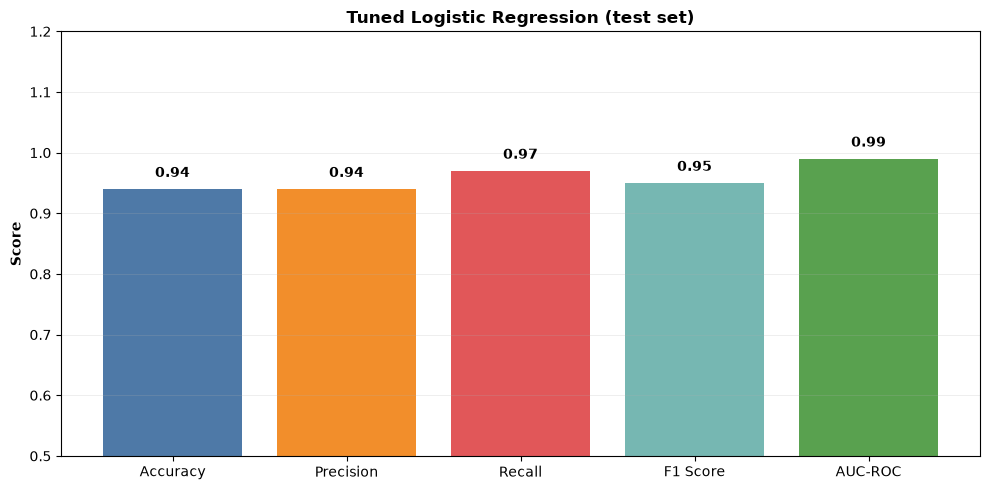

In [25]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
values = [round(accuracy, 2), round(precision, 2), round(recall, 2), round(f1, 2), round(roc, 2)]
color = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']
plt.figure(figsize=(10,5))
bars = plt.bar(metrics, values, color=color)
plt.title("Tuned Logistic Regression (test set)", fontweight='bold')
plt.ylabel("Score", fontweight='bold')
plt.ylim(0.5, 1.2)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"../figures/evaluation/model_performance.png", dpi=600, bbox_inches='tight')
plt.show()